# Séries temporelles

## Objectifs

1. **Construire** un problème de prévision avec des informations réellement disponibles.
2. **Diagnostiquer** composantes, défauts, retards et hypothèses de stationnarité.
3. **Implémenter et appliquer** références, lissage exponentiel, AR/ARIMA et régression temporelle.
4. **Comparer** des prévisions avec une validation adaptée au temps.
5. **Interpréter** erreurs, résidus, couverture et limites d’une bande de prévision.
6. **Justifier** un protocole complet et reproductible.

## Préparation

Python : variables, boucles, fonctions, tableaux et graphiques. Les rappels nécessaires sont donnés dans chaque section.
Depuis `cours/` : `python -m pip install -r requirements.txt`, puis `python -m jupyterlab notebook.ipynb`.
Les sections M03 à M08 possèdent leurs ressources indépendantes : exécutez d’abord les imports ci-dessous, puis la cellule « Ressources fournies » du module choisi. Les exercices précédents n’ont pas à être complétés pour démarrer un nouveau module.

Les données sont **simulées** ; graines fixées, petits tableaux, CPU, aucun GPU. Ne pas interpréter les performances comme celles d’un capteur réel.
Une cellule « À compléter » affiche « non vérifié » jusqu’à votre réponse. Le code fourni autour des trous n’est pas l’objet de l’exercice.

## Parcours

M01 : problème temporel · M02 : signal · M03 : autocorrélation et stationnarité · M04 : évaluation · M05 : lissage exponentiel · M06 : ARIMA · M07 : régression · M08 : étude intégratrice.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scripts.outil_ts import (signal_long, acf_simple, reference, mae, rmse,
    niveau_ses, design, fit_ridge, predict_ridge, optional_statsmodels)
SEED = 2026
plt.rcParams.update({'figure.figsize': (9, 3.5), 'axes.spines.top': False,
                     'axes.spines.right': False})
print('Imports prêts. Les observations sont indexées ; les simulations sont horaires.')

Imports prêts. Les observations sont indexées ; les simulations sont horaires.


## 1. M01 — Poser un problème temporel · TP-01

**Dans ce TP :** décrire la cible et construire plusieurs couples passé → futur sans inclure une mesure inconnue.

### 1.1 Données et notation — code fourni

Une observation peut être repérée par son indice : x[t]. Cet indice peut exister sans date connue. Dans notre exemple, les observations sont horaires : Δt=1 h. L’indice commence à zéro. À l’origine t, x[t] est déjà observé ; la cible est x[t+H].

**t** : dernier indice connu · **p** : nombre d’observations gardées · **H** : nombre de pas jusqu’à la cible.

Tracez la série avec la cellule suivante. Le futur est affiché pour observer ce qui s’est passé ; ne l’utilisez pas pour construire vos prévisions.


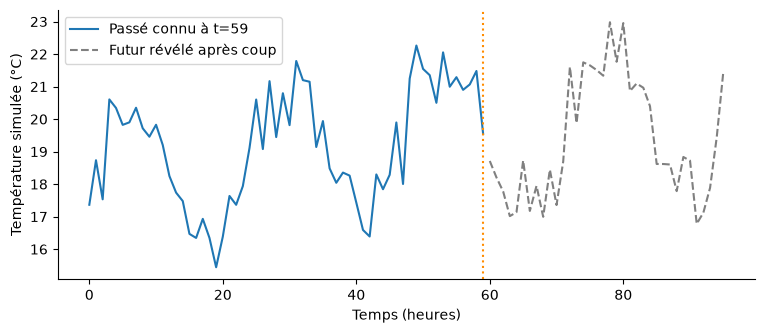

In [4]:
t = np.arange(96)
trend = 18 + 0.025 * t
seasonal = 2 * np.sin(2 * np.pi * t / 24)
noise = np.random.default_rng(SEED).normal(0, 0.8, len(t))
x_reference = trend + seasonal + noise
fig, ax = plt.subplots()
ax.plot(t[:60], x_reference[:60], label='Passé connu à t=59')
ax.plot(t[60:], x_reference[60:], '--', color='gray', label='Futur révélé après coup')
ax.axvline(59, color='darkorange', linestyle=':')
ax.set(xlabel='Temps (heures)', ylabel='Température simulée (°C)')
ax.legend(); plt.show()
assert x_reference.shape == (96,) and np.isfinite(x_reference).all()


### ACT-01 — Deux échantillonnages

Avec la présentation, avant TP-01. Ces deux cas sont indépendants du graphique précédent. Les observations sont régulièrement espacées.

À partir de la dernière observation disponible, vous visez la valeur située six pas plus tard (H = 6).

1. Une observation chaque heure : quelle durée sépare la dernière observation de la cible ?
2. Une observation chaque dix minutes : quelle durée ?

Donnez le calcul et l’unité pour chaque cas. Aucune température n’est à prédire ici.

Votre justification : …


### ACT-02 — Comparer trois règles

#### 1. Faire deux prévisions à partir du passé — en binôme, 2 min

Vous êtes à `t=59` : seules les observations jusqu’à `x[59]` sont disponibles. Ignorez la partie future si elle apparaît sur un graphique précédent. Vous voulez prévoir `x[60]` (H=1) et `x[65]` (H=6).

**Choisissez une seule des trois règles ci-dessous**, puis appliquez-la aux deux horizons. Il ne s’agit pas de deviner la suite de la courbe.

| Règle | Calcul avec les observations connues |
|---|---|
| Naïf : répéter la dernière valeur | `x[59]` aux deux horizons |
| Moyenne : répéter la moyenne récente | moyenne de `x[54:60]` aux deux horizons, soit les six valeurs des indices 54 à 59 |
| Saisonnier : reprendre la même heure la veille | `x[36]` pour H=1 ; `x[41]` pour H=6, car la période vaut 24 pas |

Utilisez `x_reference` pour lire les valeurs. Notez **la règle choisie, vos deux prévisions en °C et une raison pour laquelle cette règle pourrait se tromper**.

Règle : … · Prévision H=1 : … °C · Prévision H=6 : … °C · Limite : …

#### 2. Comparer les trois règles sur plusieurs instants

Exécutez la cellule suivante : elle applique **les trois règles**, à chacun des 66 instants de `t=24` à `t=89`, pour H=1 et H=6. À chaque instant, les nouvelles observations sont disponibles et une nouvelle prévision est émise.

Le résultat est la **MAE : la moyenne des erreurs absolues, en °C**. Une MAE plus petite indique de meilleures prévisions sur cette comparaison. Le graphique des diapos représente ces erreurs, pas les températures prédites.

Quel est le classement à H=1, puis à H=6 ? Deux scores presque égaux permettent-ils de choisir nettement ? Pourquoi le classement pourrait-il changer sur une série sans saisonnalité ?


In [7]:
# Fourni : reproduire la comparaison des slides, après les prédictions.
x_act = 18 + .025*np.arange(96) + 2*np.sin(2*np.pi*np.arange(96)/24)
x_act += np.random.default_rng(2026).normal(0,.8,96)
orig_act = np.arange(24,90)
for method in ['naif', 'moyenne', 'saisonnier']:
    scores = [mae(x_act[orig_act+h], reference(x_act, orig_act, h, method)) for h in [1,6]]
    print(method, 'MAE H=1 / H=6 :', np.round(scores,3))

naif MAE H=1 / H=6 : [1.001 1.979]
moyenne MAE H=1 / H=6 : [1.315 2.446]
saisonnier MAE H=1 / H=6 : [1.001 1.015]


### À retenir — Utiliser les données réellement disponibles

Une donnée peut figurer dans le fichier final sans avoir été disponible au moment de la prévision.

- Vérifiez **l’heure de réception ou de publication**, pas seulement l’heure de la mesure.
- Conservez **la version connue à cet instant** : une révision publiée plus tard appartient au futur.
- Une transformation des entrées doit utiliser **des valeurs déjà connues**. Une moyenne centrée qui lit une mesure future crée une fuite.

**Fuite d’information** : utiliser pour prévoir une donnée qui n’était pas encore disponible.

Exemple : à 18 h, une prévision météo publiée à 17 h peut être utilisée ; une mesure reçue à 18 h 15 et une révision publiée à 18 h 30 doivent être exclues.


### 1.2 TP-01 — Du tableau à un diagnostic de fuite

**EX-01 · 3 min :** vérification rapide individuelle. **EX-02 · 8 min :** construire X et y en binôme. **EX-03 · 15 min :** disponibilité et pipeline trompeur. Expliquez vos résultats ; revenez à la présentation pour ACT-04.

### EX-01 — Une fenêtre et sa cible

**Objectif :** Aligner des observations connues et une valeur future.  
**Durée :** 3 min · **Difficulté :** 1 — démarrage · **Travail :** Individuel, puis comparaison en binôme  
**Ressources :** toy = [3, 5, 4, 8, 7, 9, 6, 10], origine t=4, p=3, H=1 ; valeurs différentes de l’exemple guidé des slides.

**Rappel :** `t` est le dernier indice connu ; `p` est le nombre d’observations gardées, en incluant `x[t]` ; `H` est le nombre de pas jusqu’à la cible `x[t+H]`. 

**Consigne.** Écrivez sur papier les trois observations utilisables à t=4 et la cible à prévoir. Complétez ensuite les deux variables Python. Conservez l’ordre du plus ancien au plus récent.

**Résultat attendu :** Un tableau de trois valeurs et une cible scalaire ; la cible ne figure pas dans les entrées.

<details><summary>Aide 1</summary>

Quelle est la dernière valeur déjà observée ?

</details>
<details><summary>Aide 2</summary>

Une tranche Python exclut son indice de fin.

</details>
<details><summary>Aide 3</summary>

La fenêtre commence à t-p+1 ; son indice de fin est t+1.

</details>

**Erreurs fréquentes :** Confondre indice et valeur ; exclure x[t] ; inclure la cible ; inverser la fenêtre.

**Réussite :** Les indices utilisés sont 2, 3, 4 pour les entrées et 5 pour la cible.

In [8]:
toy = np.array([3, 5, 4, 8, 7, 9, 6, 10])
origin, p, H = 4, 3, 1
# À compléter : tableau de p valeurs et cible scalaire
fenetre = None
cible = None


In [9]:
if fenetre is None or cible is None:
    print('EX-01 : à compléter — non vérifié.')
else:
    np.testing.assert_array_equal(fenetre, [4, 8, 7])
    assert cible == 9
    print('EX-01 : vérification réussie.')


EX-01 : à compléter — non vérifié.


Pourquoi x[4] appartient-il aux entrées, alors que x[5] appartient à la cible ?

Votre réponse : …


### EX-02 — Déplacer la fenêtre

**Objectif :** Construire plusieurs couples passé → futur sans décalage accidentel.  
**Durée :** 8 min · **Difficulté :** 2 — application · **Travail :** Binôme, rôles alternés  
**Ressources :** toy ; fonction make_windows ; p=3, H=1 ; tests supplémentaires fournis.

**Rappel :** `t` est le dernier indice connu ; `p` est le nombre d’observations gardées, en incluant `x[t]` ; `H` est le nombre de pas jusqu’à la cible `x[t+H]`. 

**Consigne.** Complétez les deux lignes marquées À compléter dans la boucle. Exécutez les tests puis affichez la première et la dernière paire. Expliquez pourquoi on ne peut pas créer une cible après la fin du tableau.

**Résultat attendu :** X de forme (5,3), y de forme (5,), origines de forme (5,) pour toy, p=3, H=1.

<details><summary>Aide 1</summary>

Quel est le premier indice possédant trois observations ?

</details>
<details><summary>Aide 2</summary>

L’origine parcourt p-1 à N-H-1 inclus.

</details>
<details><summary>Aide 3</summary>

Dans la boucle, xs.append(series[t-p+1:t+1]) construit les entrées. Il reste à trouver la cible.

</details>

**Erreurs fréquentes :** Oublier H ; utiliser x[t] comme cible ; garder une cible hors tableau ; changer l’ordre temporel.

**Réussite :** Tests sur deux horizons réussis ; première et dernière paire expliquées.

In [ ]:
def make_windows(series, p=3, H=1):
    series = np.asarray(series)
    if p < 1 or H < 1 or len(series) < p + H:
        raise ValueError('Il faut p>=1, H>=1 et N>=p+H.')
    xs, ys, origins = [], [], []
    for t in range(p-1, len(series)-H):
        # À compléter : remplacez les deux None
        window = None
        target = None
        if window is None or target is None:
            return None
        xs.append(window)
        ys.append(target)
        origins.append(t)
    return np.asarray(xs), np.asarray(ys), np.asarray(origins)

paires = make_windows(toy)


In [ ]:
if paires is None:
    print('EX-02 : à compléter — non vérifié.')
else:
    X, y, origins = paires
    assert X.shape == (5, 3) and y.shape == (5,)
    np.testing.assert_array_equal(origins, [2, 3, 4, 5, 6])
    np.testing.assert_array_equal(X[0], [3, 5, 4])
    np.testing.assert_array_equal(X[-1], [7, 9, 6])
    np.testing.assert_array_equal(y, [8, 7, 9, 6, 10])
    X2, y2, o2 = make_windows(np.arange(10), p=3, H=2)
    assert X2.shape == (6, 3)
    np.testing.assert_array_equal(y2, [4, 5, 6, 7, 8, 9])
    np.testing.assert_array_equal(o2, [2, 3, 4, 5, 6, 7])
    print('EX-02 : vérification réussie. Première / dernière paire :')
    print(X[0], '→', y[0], ';', X[-1], '→', y[-1])


Que devient le nombre d’exemples lorsque H passe de 1 à 2 ? Distinguez un horizon H=2 de la production de deux cibles simultanées.

Votre réponse : …


### EX-03 — Disponibilité et pipeline trompeur

**Objectif :** diagnostiquer et corriger une fuite. **Temps :** 15 min. **Difficulté :** 2. **Travail :** binôme. **Ressources :** code fourni ci-dessous.

**t** : indice où la prévision est émise. Ici **H = 1** : on prévoit la valeur au pas suivant, `x[t+1]`.

1. Exécutez les deux cellules fournies. Repérez la cible, l’entrée du modèle et le score obtenu.
2. Expliquez pourquoi ce score parfait ne correspond pas à une prévision réalisable à t.
3. Complétez `X_corrige` avec une entrée connue à chaque origine, puis comparez les deux MAE.
4. Lisez le test qui change les valeurs futures : expliquez pourquoi l’entrée corrigée reste identique à l’origine 60, tandis que l’entrée fautive change.

**Résultat :** une entrée corrigée, deux MAE et une explication du test.

<details><summary>Aide 1</summary>Comparez les indices utilisés pour y_bad et X_bad.</details>
<details><summary>Aide 2</summary>La cible a-t-elle été copiée dans les entrées ?</details>
<details><summary>Aide 3</summary>Pour prévoir x[t+1], x[t] est une entrée disponible.</details>

**Erreurs :** accepter un score sans examiner les entrées ; interpréter une MAE plus élevée comme une correction ratée. **Réussite :** test d’invariance réussi et fuite expliquée.


In [ ]:
# Fourni : données et programme à examiner.
orig_bad = np.arange(24,90)
y_bad = x_act[orig_bad+1]
X_bad = x_act[orig_bad+1]


In [ ]:
# Fourni : observer le score et un exemple d’entrée/cible.
print('MAE suspecte :', mae(y_bad, X_bad))
print('À l’origine 24 : entrée =', X_bad[0], '; cible =', y_bad[0])


In [ ]:
X_corrige = None  # À compléter : une entrée connue à chaque origine.
if X_corrige is None:
    print('EX-03 : à compléter — non vérifié.')
else:
    np.testing.assert_array_equal(X_corrige, x_act[orig_bad])
    print('MAE corrigée :', mae(y_bad, X_corrige))
    # À l’origine 60, les indices à partir de 61 appartiennent au futur.
    changed = x_act.copy()
    changed[61:] += 100
    X_corrige_changed = changed[orig_bad]
    np.testing.assert_array_equal(X_corrige_changed[orig_bad <= 60], X_corrige[orig_bad <= 60])
    X_bad_changed = changed[orig_bad+1]
    assert X_bad_changed[orig_bad == 60][0] != X_bad[orig_bad == 60][0]
    print('EX-03 : correction vérifiée ; changer le futur ne change pas les entrées déjà connues.')


### ACT-04 — Vérification flash et diagnostic

Individuel, 30 s : x=[2,4,6,8,10,12], t=3, p=2, H=2. Entrées et cible ?
Puis : pourquoi ajouter x[t+H] aux entrées produit-il un score trompeur ?

## 2. M02 — Explorer et préparer un signal · TP-02

**Dans ce TP :** décrire un signal, calculer une moyenne causale et traiter une absence sans consulter le futur.

### 2.1 Lire avant de transformer

Le modèle de simulation est **x[t] = tendance[t] + saisonnalité[t] + bruit[t]**. Les composantes sont connues ici parce que nous les générons. Sur une série réelle, elles ne sont pas directement observées et leur séparation dépend d’hypothèses.

La saisonnalité de notre capteur fictif est de période 24 h. Une oscillation quelconque n’a pas nécessairement une période fixe.


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for ax, vals, name in zip(axes, [trend, seasonal, noise], ['Tendance', 'Saisonnalité', 'Bruit simulé']):
    ax.plot(t, vals); ax.set_ylabel(name)
axes[-1].set_xlabel('Temps (heures)'); plt.tight_layout(); plt.show()


### ACT-05 — Quel paramètre modifier ?

**Avec la présentation, avant TP-02.** Pour monter progressivement le niveau, augmenter les pics quotidiens ou ajouter des fluctuations irrégulières, quelle composante et quel paramètre faut-il modifier ?

Votre justification : …


### ACT-06 — Qui connaît le futur ?

**Avec la présentation, avant TP-02.** Une moyenne de x[t-1], x[t], x[t+1] est-elle calculable dès l’arrivée de x[t] ?

Votre justification : …


### ACT-07 — Que vérifier avant de supprimer ?

**Avec la présentation, avant TP-02.** Une valeur très élevée revient au niveau habituel : proposez deux explications et une information pour les départager. Quelle différence observable sépare ce pic d’une rupture de niveau ?

Votre justification : …


### 2.2 TP-02 — Composantes, lissage et données manquantes

Relisez les ressources et exécutez les cellules fournies.  
**EX-04 · 5 min.**  
**EX-05 · 9 min.**  
**EX-06 · 6 min.**  
Revenez ensuite à la présentation pour ACT-08 et la synthèse.


### EX-04 — Construire puis modifier un signal

**Objectif :** Relier des paramètres à la tendance, à la saisonnalité et au bruit.  
**Durée :** 5 min · **Difficulté :** 1 — application · **Travail :** Binôme  
**Ressources :** 96 observations horaires ; pente 0.025 ; amplitude 2 ; période 24 ; sigma 0.8 ; graine 2026.

**Consigne.** Complétez la somme des trois composantes. Fixez ensuite amplitude=0, réexécutez la cellule puis remettez amplitude=2. Décrivez le changement en une phrase.

**Résultat attendu :** Signal de 96 valeurs ; graphique annoté ; interprétation de la suppression du motif périodique.

<details><summary>Aide 1</summary>

Les contributions s’ajoutent-elles ou se multiplient-elles ?

</details>
<details><summary>Aide 2</summary>

Le niveau 18 est déjà inclus dans trend.

</details>
<details><summary>Aide 3</summary>

x_simule = trend + seasonal + noise. Repérez dans le graphique ce qui disparaît lorsque amplitude vaut 0.

</details>

**Erreurs fréquentes :** Ajouter deux fois le niveau ; confondre amplitude et période ; conclure que tout bruit disparaît.

**Réussite :** Identité additive vérifiée ; interprétation correcte ; paramètres restaurés.


In [ ]:
amplitude, slope, sigma = 2., 0.025, 0.8
trend = 18 + slope * t
seasonal = amplitude * np.sin(2 * np.pi * t / 24)
noise = sigma * np.random.default_rng(SEED).normal(0, 1, len(t))
# À compléter : combinez les composantes.
x_simule = None


In [ ]:
if x_simule is None:
    print('EX-04 : à compléter — non vérifié.')
else:
    assert x_simule.shape == (96,)
    np.testing.assert_allclose(x_simule-trend-seasonal, noise, atol=1e-12)
    plt.plot(t, x_simule); plt.xlabel('Temps (heures)')
    plt.ylabel('Température simulée (°C)'); plt.show()
    print('EX-04 : vérification réussie.')


Que reste-t-il quand amplitude=0 ? Que change sigma=0 ? Peut-on connaître exactement le bruit d’une vraie série ?

Votre réponse : …


### EX-05 — Lisser sans connaître le futur

**Objectif :** Implémenter une moyenne mobile causale et identifier son compromis bruit/retard.  
**Durée :** 9 min · **Difficulté :** 2 — application · **Travail :** Binôme  
**Ressources :** x_reference ; fenêtres w=3 et w=13 ; saut de niveau fourni.

**Consigne.** Complétez la tranche utilisée par trailing_mean. Exécutez les tests. Comparez w=3 et w=13 ; expliquez le retard du lissage au voisinage du saut. Les w-1 premières sorties restent NaN.

**Résultat attendu :** Moyenne à t calculée avec les seuls indices t-w+1 à t ; graphique comparatif ; explication du retard.

<details><summary>Aide 1</summary>

À t, quelles observations sont déjà arrivées ?

</details>
<details><summary>Aide 2</summary>

Le dernier indice inclus doit être t.

</details>
<details><summary>Aide 3</summary>

np.mean(values[t-w+1:t+1]) calcule une fenêtre complète se terminant à t.

</details>

**Erreurs fréquentes :** Fenêtre centrée ; moyenne cumulative à la place d’une fenêtre fixe ; remplissage des bords avec zéro ; confondre lissage et prévision.

**Réussite :** Test sur tableau court et test d’invariance au futur réussis ; compromis expliqué.


In [ ]:
def trailing_mean(values, w):
    values = np.asarray(values, dtype=float)
    if not isinstance(w, (int, np.integer)) or w < 1 or w > len(values):
        raise ValueError('w doit être un entier entre 1 et N.')
    out = np.full(len(values), np.nan)
    for t in range(w-1, len(values)):
        # À compléter : remplacez None par la moyenne de la bonne tranche.
        local_mean = None
        if local_mean is None:
            return None
        out[t] = local_mean
    return out

smooth3 = trailing_mean(x_reference, 3)
smooth13 = trailing_mean(x_reference, 13)


In [ ]:
if smooth3 is None or smooth13 is None:
    print('EX-05 : à compléter — non vérifié.')
else:
    z = trailing_mean([1,2,3,4,5], 3)
    assert np.isnan(z[:2]).all()
    np.testing.assert_allclose(z[2:], [2,3,4])
    # Modifier le futur ne doit pas changer les sorties déjà calculées.
    changed = x_reference.copy(); changed[60:] += 1000
    np.testing.assert_allclose(trailing_mean(changed,3)[:60], smooth3[:60], equal_nan=True)
    plt.plot(t,x_reference, alpha=.4, label='Signal')
    plt.plot(t,smooth3,label='Causal w=3'); plt.plot(t,smooth13,label='Causal w=13')
    plt.xlabel('Temps (heures)'); plt.ylabel('Température simulée (°C)')
    plt.legend(); plt.show()
    print('EX-05 : tests numérique et causal réussis.')


In [ ]:
# Démonstration fournie : le calcul centré est rétrospectif.
step_signal = np.r_[np.zeros(25), np.ones(25)*4]
centered = np.full(50, np.nan)
for k in range(2, 48):
    centered[k] = np.mean(step_signal[k-2:k+3])
if smooth3 is not None:
    causal = trailing_mean(step_signal, 5)
    plt.plot(step_signal,label='Saut réel à t=25')
    plt.plot(causal,label='Causal w=5'); plt.plot(centered,'--',label='Centré w=5')
    plt.xlim(18,32); plt.xlabel('Temps (pas)'); plt.ylabel('Signal (u.a.)')
    plt.legend(); plt.show()
else:
    print('Complétez EX-05 pour afficher la comparaison.')


À quelle date le lissage centré commence-t-il à monter ? Pourquoi ? Le lissage causal « prédit-il » le saut ?

Votre réponse : …


### EX-06 — Traiter une absence sans effacer un événement

**Objectif :** Appliquer un report causal limité et discuter un pic isolé.  
**Durée :** 6 min · **Difficulté :** 2 — application · **Travail :** Binôme  
**Ressources :** Copie de x_reference : NaN aux indices 30:33 ; pic artificiel +8 à l’indice 65.

**Consigne.** Complétez forward_fill en conservant la dernière valeur observée. Vérifiez le comportement quand la série commence par NaN. Sur le graphique, distinguez le trou, le pic et un changement durable. Proposez une règle de prudence pour les trous longs.

**Résultat attendu :** Série complétée uniquement après une valeur connue ; indicateur de manque conservé ; commentaire sur le pic.

<details><summary>Aide 1</summary>

Quelle valeur garder en mémoire quand une observation arrive ?

</details>
<details><summary>Aide 2</summary>

Un NaN initial ne peut pas être remplacé par une observation passée inexistante.

</details>
<details><summary>Aide 3</summary>

Dans le cas observé : last = value. Dans le cas manquant : out[i] = last.

</details>

**Erreurs fréquentes :** Interpolation entre passé et futur pour une tâche en ligne ; remplacement initial par la moyenne complète ; suppression automatique des pics.

**Réussite :** Tests incluant un NaN initial réussis ; masque manquant conservé ; politique pour trous longs discutée.


In [ ]:
x_defects = x_reference.copy()
x_defects[30:33] = np.nan
x_defects[65] += 8
missing_mask = np.isnan(x_defects)
plt.plot(t,x_defects); plt.xlabel('Temps (heures)')
plt.ylabel('Température simulée (°C)'); plt.show()
print('Indices manquants :', np.flatnonzero(missing_mask))


In [ ]:
def forward_fill(values):
    out = np.asarray(values, dtype=float).copy()
    last = np.nan
    for i, value in enumerate(out):
        if np.isnan(value):
            # À compléter : reporter la dernière valeur connue.
            replacement = None
            if replacement is None:
                return None
            out[i] = replacement
        else:
            # À compléter : mémoriser l'observation présente.
            last = None
    return out

x_filled = forward_fill(x_defects)


In [ ]:
if x_filled is None:
    print('EX-06 : à compléter — non vérifié.')
else:
    trial = forward_fill([np.nan,2,np.nan,np.nan,5])
    assert np.isnan(trial[0])
    np.testing.assert_allclose(trial[1:], [2,2,2,5])
    np.testing.assert_allclose(x_filled[30:33], np.repeat(x_reference[29],3))
    np.testing.assert_allclose(x_filled[~missing_mask], x_defects[~missing_mask])
    assert missing_mask.sum() == 3
    changed = x_defects.copy(); changed[60:] = 1000
    np.testing.assert_allclose(forward_fill(changed)[:60], x_filled[:60], equal_nan=True)
    plt.plot(t,x_defects,label='Avec défauts')
    plt.scatter(t[missing_mask], x_filled[missing_mask], color='darkorange',label='Report causal')
    plt.xlabel('Temps (heures)'); plt.ylabel('Température simulée (°C)')
    plt.legend(); plt.show()
    print('EX-06 : vérification réussie ; le masque initial est conservé.')


L’absence d’erreur Python prouve-t-elle que le report représente la vraie température ? Quelle information perdrait-on en supprimant missing_mask ? Pourquoi ne pas supprimer tous les pics ?

Votre réponse : …


### ACT-08 — Retour à la présentation

Vrai ou faux, justifié : une fenêtre plus grande réagit plus vite ; un trou initial peut être rempli par report causal ; un pic doit toujours être supprimé.

Votre justification : …


## 3. M03 — Autocorrélation et stationnarité · TP-03

**Objectifs :** Calculer une ACF, appliquer une différence et distinguer stationnarité et bruit blanc

**Prérequis :** moyenne, variance, indices. Exécutez les imports, puis les ressources ci-dessous.

Travaillez en binôme sur les trois exercices (7, 9 et 9 min). Discutez les questions ACT avant et après le TP, puis reprenez les diapos.

In [ ]:
# Ressources fournies : indépendantes des exercices précédents.
t_long, x_long = signal_long()
H_long = 6
ARIMA, ExponentialSmoothing = optional_statsmodels()
rng3=np.random.default_rng(2030)
eps3=rng3.normal(size=240)
ar3=np.zeros(240)
for i in range(1,240): ar3[i]=.7*ar3[i-1]+eps3[i]
rw3=np.cumsum(eps3)
fig,axes=plt.subplots(3,1,figsize=(9,5),sharex=True)
for ax,z,label in zip(axes,[eps3,ar3,rw3],['Bruit','AR(1)','Marche aléatoire']):
    ax.plot(z);ax.set_ylabel(label)
axes[-1].set_xlabel('Indice');plt.show()

### ACT-09 — Avec la présentation

Classez qualitativement les corrélations au retard 1 des trois processus.

Votre réponse et justification : …

### ACT-10 — Avec la présentation

Deux séries montent ensemble : une forte corrélation prouve-t-elle un lien causal ?

Votre réponse et justification : …

### ACT-11 — Avec la présentation

Quel premier diagnostic après une différence saisonnière ?

Votre réponse et justification : …

### EX-07 — Calculer une ACF

**Objectif :** Implémenter la convention globale de l’ACF.
**Temps :** 7 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez le numérateur de la fonction, puis tracez les ACF du bruit et de l’AR. Expliquez le signe à k=1 pour [1,2,1,2].

**Résultat attendu :** Deux courbes et une justification de r1=−0,75.

<details><summary>Aide 1</summary>Centrez avec une moyenne globale.</details>

<details><summary>Aide 2</summary>Comparez z[k:] et z[:-k].</details>

<details><summary>Aide 3</summary>Le produit scalaire est z[k:] @ z[:len(z)-k].</details>

**Erreurs fréquentes :** Recentrer chaque tranche ; oublier le dénominateur commun.

**Réussite :** Cas papier exact et invariance à une translation réussis.

In [ ]:
def acf_a_completer(values,maxlag=12):
    z=np.asarray(values,float)-np.mean(values)
    out=[1.]
    for k in range(1,maxlag+1):
        numerator=None  # À compléter
        if numerator is None: return None
        out.append(numerator/(z@z))
    return np.asarray(out)
acf_result=acf_a_completer(ar3)

In [ ]:
if acf_result is None: print('EX-07 : à compléter — non vérifié.')
else:
    np.testing.assert_allclose(acf_a_completer([1,2,1,2],1),[1,-.75])
    np.testing.assert_allclose(acf_result,acf_a_completer(ar3+100))
    assert np.all(np.abs(acf_result)<=1+1e-12)
    print('EX-07 : vérification réussie.')
    for zz,label in [(eps3,'Bruit'),(ar3,'AR')]:plt.plot(acf_a_completer(zz),label=label)
    plt.xlabel('Retard');plt.ylabel('ACF');plt.legend();plt.show()

Une translation du niveau change-t-elle l’ACF ? Pourquoi ?

Votre interprétation : …

### EX-08 — Différencier et reconstruire

**Objectif :** Relier transformation, longueur et unité.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez la différence saisonnière, reconstruisez le signal à partir des différences au pas 1, puis comparez les ACF.

**Résultat attendu :** N−24 différences saisonnières ; reconstruction exacte des observations, puis interprétation.

<details><summary>Aide 1</summary>À quelle observation faut-il comparer x[t] ?</details>

<details><summary>Aide 2</summary>Alignez x[24:] et x[:-24].</details>

<details><summary>Aide 3</summary>La reconstruction commence par x[0], puis utilise une somme cumulée.</details>

**Erreurs fréquentes :** Oublier le niveau initial ; présenter une reconstruction comme une prévision.

**Réussite :** Longueurs correctes et reconstruction égale au signal.

In [ ]:
d1=np.diff(x_long)
d24=None  # À compléter
recon=None  # À compléter

In [ ]:
if d24 is None or recon is None: print('EX-08 : à compléter — non vérifié.')
else:
    assert len(d24)==len(x_long)-24
    np.testing.assert_allclose(d24,x_long[24:]-x_long[:-24])
    np.testing.assert_allclose(recon,x_long)
    print('EX-08 : vérification réussie.')
    for zz,label in [(x_long,'Brute'),(d1,'Différence 1'),(d24,'Différence 24')]:plt.plot(acf_simple(zz,36),label=label)
    plt.xlabel('Retard');plt.ylabel('ACF');plt.legend();plt.show()

Quels effets restent après différence saisonnière ? Pourquoi la reconstruction exacte n’est-elle pas une réussite prédictive ?

Votre interprétation : …

### EX-09 — Diagnostiquer des propriétés

**Objectif :** Distinguer dépendance, stationnarité et hypothèse statistique.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez les trois décisions ; justifiez en deux phrases. Facultatif : exécutez le test ADF fourni sur le bruit et la marche aléatoire.

**Résultat attendu :** Trois décisions avec hypothèses explicites.

<details><summary>Aide 1</summary>Un processus peut-il fluctuer autour d’un niveau tout en étant corrélé ?</details>

<details><summary>Aide 2</summary>Stationnarité concerne les moments ; bruit blanc ajoute autocovariance nulle.</details>

<details><summary>Aide 3</summary>Un non-rejet n’est pas une preuve.</details>

**Erreurs fréquentes :** Déduire indépendance de corrélation nulle ; prendre une p-valeur pour une preuve.

**Réussite :** Décisions correctes et distinction de l’hypothèse nulle expliquée.

In [ ]:
decisions3={'ar_stationnaire_peut_etre_previsible':None,
            'acf_nulle_prouve_independance':None,
            'non_rejet_adf_prouve_racine_unitaire':None}
# Facultatif, fourni : test ADF, hypothèse nulle de racine unitaire.
if all(v is not None for v in decisions3.values()):
    try:
        from statsmodels.tsa.stattools import adfuller
        for z,label in [(eps3,'Bruit'),(rw3,'Marche aléatoire')]:
            result=adfuller(z,maxlag=4,regression='c',autolag='AIC')
            print(label,'p ADF :',round(result[1],4))
    except ImportError:
        print('Extension ADF : statsmodels nécessaire.')

In [ ]:
if any(v is None for v in decisions3.values()): print('EX-09 : à compléter — non vérifié.')
else:
    assert list(decisions3.values())==[True,False,False]
    print('EX-09 : vérification réussie ; justifiez les hypothèses.')

Quelle différence entre le processus stationnaire théorique et cette courte réalisation ?

Votre interprétation : …

### ACT-12 — Avec la présentation

Vrai ou faux : stationnaire implique imprévisible.

Votre réponse et justification : …

## 4. M04 — Évaluer une prévision · TP-04

**Objectifs :** Partager selon les cibles, calculer MAE/RMSE et auditer la disponibilité

**Prérequis :** modules précédents. Exécutez les imports, puis les ressources ci-dessous.

Travaillez en binôme sur les trois exercices (7, 9 et 9 min). Discutez les questions ACT avant et après le TP, puis reprenez les diapos.

In [ ]:
# Ressources fournies : indépendantes des exercices précédents.
t_long, x_long = signal_long()
H_long = 6
ARIMA, ExponentialSmoothing = optional_statsmodels()
orig4=np.arange(24,len(x_long)-6)
targets4=orig4+6
# Les références consomment uniquement des observations déjà connues à chaque origine.
pred4=reference(x_long,orig4,6,'saisonnier')
y4=x_long[targets4]

### ACT-13 — Avec la présentation

Un partage aléatoire évalue-t-il correctement les prochaines semaines ?

Votre réponse et justification : …

### ACT-14 — Avec la présentation

Calculez MAE/RMSE pour erreurs A=[0,0,6], B=[3,3,3].

Votre réponse et justification : …

### ACT-15 — Avec la présentation

mu=x.mean() avant partage : quel problème ?

Votre réponse et justification : …

### EX-10 — Partager par date cible

**Objectif :** Préserver la disponibilité des étiquettes d’apprentissage.
**Temps :** 7 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez les masques apprentissage et validation ; affichez première et dernière origine de chaque bloc.

**Résultat attendu :** Cibles apprentissage <288, validation 288–383 ; frontière expliquée.

<details><summary>Aide 1</summary>Où tombe la cible d’une origine 285 ?</details>

<details><summary>Aide 2</summary>Utilisez targets4, pas seulement orig4.</details>

<details><summary>Aide 3</summary>Le masque d’apprentissage est targets4 < 288.</details>

**Erreurs fréquentes :** Partager uniquement les origines ; inclure des cibles futures en apprentissage.

**Réussite :** Aucune cible train après la frontière et aucun recouvrement des masques.

In [ ]:
train4=None  # À compléter
valid4=None  # À compléter

In [ ]:
if train4 is None or valid4 is None: print('EX-10 : à compléter — non vérifié.')
else:
    assert targets4[train4].max()==287 and orig4[train4].max()==281
    assert targets4[valid4].min()==288 and targets4[valid4].max()==383
    assert not np.any(train4&valid4)
    print('EX-10 : vérification réussie.')

Pourquoi les premières prévisions de validation ont-elles des origines antérieures à 288 ?

Votre interprétation : …

### EX-11 — Comparer des références

**Objectif :** Calculer une métrique et comparer des cibles identiques.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez la fonction MAE, puis exécutez la comparaison fournie pour H=1 et H=6 sur la sélection 288–335.

**Résultat attendu :** Tableau six scores, classement et limites.

<details><summary>Aide 1</summary>Calculez l’écart absolu avant la moyenne.</details>

<details><summary>Aide 2</summary>Les indices de cibles doivent rester identiques par horizon.</details>

<details><summary>Aide 3</summary>np.mean(np.abs(y-p)) est la MAE.</details>

**Erreurs fréquentes :** Comparer des périodes différentes ; confondre RMSE et MSE.

**Réussite :** Cas papier vérifié et invariance au signe des erreurs.

In [ ]:
def mae_a_completer(y,p):
    return None  # À compléter
score11=mae_a_completer(np.array([0,0,6]),np.zeros(3))

In [ ]:
if score11 is None: print('EX-11 : à compléter — non vérifié.')
else:
    assert score11==2
    assert np.isclose(rmse([0,0,6],[0,0,0]),np.sqrt(12))
    assert mae_a_completer([1,-2],[0,0])==mae_a_completer([-1,2],[0,0])
    print('EX-11 : vérification réussie.')

Quel coût d’erreur ferait préférer RMSE ? Que risque MAPE en °C ?

Votre interprétation : …

In [ ]:
if score11 is not None:
    for h in [1,6]:
        oo=np.arange(288-h,336-h)
        for method in ['naif','moyenne','saisonnier']:
            pp=reference(x_long,oo,h,method)
            print(h,method,round(mae_a_completer(x_long[oo+h],pp),3))

### EX-12 — Auditer un pipeline

**Objectif :** Séparer représentation causale et apprentissage sur le futur.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez le centrage d’apprentissage. Expliquez pourquoi les observations nouvellement reçues pendant le test peuvent être utilisées si la prévision est réémise.

**Résultat attendu :** Paramètre appris sur 0–287 et une fiche de protocole.

<details><summary>Aide 1</summary>Quelles dates contribuent à mu ?</details>

<details><summary>Aide 2</summary>Le modèle peut rester fixe pendant que ses entrées évoluent.</details>

<details><summary>Aide 3</summary>mu=x_long[:288].mean().</details>

**Erreurs fréquentes :** Confondre réémission et bloc fixe ; normaliser sur tout le fichier.

**Réussite :** Paramètre invariant si seules les données futures changent.

In [ ]:
mu12=None  # À compléter
fiche12='H=6 ; réémission horaire ; paramètres fixes ; MAE ; saisonnier'

In [ ]:
if mu12 is None: print('EX-12 : à compléter — non vérifié.')
else:
    changed=x_long.copy();changed[288:]+=100
    assert np.isclose(mu12,changed[:288].mean())
    assert not np.isclose(mu12,changed.mean())
    print('EX-12 : vérification réussie ; expliquez le scénario de disponibilité.')

Une frontière chronologique suffit-elle si les données arrivent avec retard ?

Votre interprétation : …

### ACT-16 — Avec la présentation

Un chevauchement de fenêtres est-il forcément une fuite ?

Votre réponse et justification : …

## 5. M05 — Lissage exponentiel · TP-05

**Objectifs :** Mettre à jour un niveau, choisir alpha et appliquer Holt-Winters

**Prérequis :** récursion et validation. Exécutez les imports, puis les ressources ci-dessous.

Travaillez en binôme sur les trois exercices (7, 9 et 9 min). Discutez les questions ACT avant et après le TP, puis reprenez les diapos.

In [ ]:
# Ressources fournies : indépendantes des exercices précédents.
t_long, x_long = signal_long()
H_long = 6
ARIMA, ExponentialSmoothing = optional_statsmodels()
z5=np.r_[np.ones(30)*10,np.ones(30)*14]+np.random.default_rng(5).normal(0,.4,60)
plt.plot(z5);plt.xlabel('Indice');plt.ylabel('Niveau simulé');plt.show()

### ACT-17 — Avec la présentation

Mémoire courte ou longue après un saut ? Et si c’était un pic erroné ?

Votre réponse et justification : …

### ACT-18 — Avec la présentation

x[t]−level[t], après mise à jour avec x[t], est-il une erreur de prévision ?

Votre réponse et justification : …

### ACT-19 — Avec la présentation

Associez niveau stable, tendance seule, tendance+saison aux trois modèles.

Votre réponse et justification : …

### EX-13 — Implémenter un niveau SES

**Objectif :** Respecter l’ordre observation, mise à jour et prévision.
**Temps :** 7 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez la mise à jour. Comparez alpha=0,15 et 0,8 sur le saut ; distinguez niveau courant et prévision à un pas.

**Résultat attendu :** Deux niveaux et calcul manuel 10 → 11 → 11,25 à alpha=0,25.

<details><summary>Aide 1</summary>Quelle quantité est connue à t ?</details>

<details><summary>Aide 2</summary>Le poids restant porte sur le niveau précédent.</details>

<details><summary>Aide 3</summary>alpha*x[i]+(1-alpha)*levels[i-1].</details>

**Erreurs fréquentes :** Évaluer x[t] contre le niveau déjà mis à jour ; inverser alpha.

**Réussite :** Cas manuel et limite alpha=1 vérifiés.

In [ ]:
def ses_a_completer(values,alpha):
    levels=np.empty(len(values));levels[0]=values[0]
    for i in range(1,len(values)):
        value=None  # À compléter
        if value is None: return None
        levels[i]=value
    return levels
ses13=ses_a_completer(z5,.15)

In [ ]:
if ses13 is None: print('EX-13 : à compléter — non vérifié.')
else:
    np.testing.assert_allclose(ses_a_completer([10,14,12],.25),[10,11,11.25])
    np.testing.assert_allclose(ses_a_completer(z5,1),z5)
    changed=z5.copy();changed[40:]+=100
    np.testing.assert_allclose(ses_a_completer(changed,.15)[:40],ses13[:40])
    print('EX-13 : vérification réussie.')

Pourquoi un alpha élevé rend-il l’erreur de filtrage petite sans garantir une bonne prévision ?

Votre interprétation : …

### EX-14 — Sélectionner alpha

**Objectif :** Comparer des prévisions réémises sur la même validation.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez le calcul des MAE à H=6 pour les trois alpha. Utilisez les niveaux disponibles à chaque origine ; rapportez le meilleur alpha et une limite.

**Résultat attendu :** Trois scores sur cibles 288–335 ; aucun test final.

<details><summary>Aide 1</summary>La cible à t+6 doit être comparée au niveau t.</details>

<details><summary>Aide 2</summary>origines=dates_cibles−6.</details>

<details><summary>Aide 3</summary>mae(x_long[origines+6], levels[origines]).</details>

**Erreurs fréquentes :** Décaler la prévision jusqu’à la cible ; utiliser le test pour choisir.

**Réussite :** Scores égaux au calcul causal de référence.

In [ ]:
alphas14=[.1,.3,.7]
origines14=np.arange(288-6,336-6)
scores14=None  # À compléter : liste de trois MAE

In [ ]:
if scores14 is None: print('EX-14 : à compléter — non vérifié.')
else:
    expected=[mae(x_long[origines14+6],niveau_ses(x_long[:336],a)[origines14]) for a in alphas14]
    np.testing.assert_allclose(scores14,expected)
    assert len(scores14)==3 and min(scores14)>=0
    print('EX-14 : vérification réussie.')

Pourquoi le calcul sur x[:336] ne provoque-t-il pas une fuite pour un niveau à t antérieur ?

Votre interprétation : …

### EX-15 — Ajouter une saisonnalité

**Objectif :** Appliquer un modèle et préciser son scénario.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez fit15 et pred15. Ajustez Holt-Winters additif sur 0–287 et prévoyez le bloc 288–311 depuis l’origine 287. Comparez au saisonnier émis à la même origine.

**Résultat attendu :** 24 prévisions, deux MAE et un graphique.

<details><summary>Aide 1</summary>L’ajustement reçoit x[:288].</details>

<details><summary>Aide 2</summary>trend et seasonal valent add, période 24.</details>

<details><summary>Aide 3</summary>ExponentialSmoothing(...).fit().forecast(24).</details>

**Erreurs fréquentes :** Mettre à jour avec les vraies mesures du bloc ; comparer à un saisonnier réémis.

**Réussite :** Forme (24,), pas de futur dans l’ajustement, origine unique expliquée.

In [ ]:
fit15=None  # À compléter : modèle ajusté sur x_long[:288]
pred15=None  # À compléter : 24 prévisions, si statsmodels est disponible
if ExponentialSmoothing is None:
    print('Installez statsmodels pour ce modèle ; utilisez le poste du binôme.')

In [ ]:
if pred15 is None: print('EX-15 : à compléter — non vérifié.')
else:
    assert np.asarray(pred15).shape==(24,) and np.isfinite(pred15).all()
    assert fit15.model.nobs==288
    print('EX-15 : vérification réussie ; justifiez l’origine fixe et la comparaison.')

Que changerait une réémission horaire ?

Votre interprétation : …

### ACT-20 — Avec la présentation

Une erreur nulle à alpha=1 prouve-t-elle une bonne prévision ?

Votre réponse et justification : …

## 6. M06 — AR, ARMA et ARIMA · TP-06

**Objectifs :** Estimer AR(1), interpréter p,d,q et comparer des blocs futurs

**Prérequis :** M03 et M04. Exécutez les imports, puis les ressources ci-dessous.

Travaillez en binôme sur les trois exercices (7, 9 et 9 min). Discutez les questions ACT avant et après le TP, puis reprenez les diapos.

In [ ]:
# Ressources fournies : indépendantes des exercices précédents.
t_long, x_long = signal_long()
H_long = 6
ARIMA, ExponentialSmoothing = optional_statsmodels()
eps6=np.random.default_rng(2027).normal(0,.7,180)
d6=np.empty(180);d6[0]=.1
for i in range(1,180):d6[i]=.1+.55*d6[i-1]+eps6[i]
z6=10+np.cumsum(d6)
# 0–119 : apprentissage ; 120–143 : validation ; 144–179 : test réservé.
train6=z6[:120]
plt.plot(z6[:144]);plt.xlabel('Indice');plt.ylabel('Valeur simulée');plt.show()

### ACT-21 — Avec la présentation

c=1, phi=.5, x[t]=10 : deux prévisions sans nouvelle mesure ?

Votre réponse et justification : …

### ACT-22 — Avec la présentation

MA(3) est-il la moyenne des trois dernières observations ?

Votre réponse et justification : …

### ACT-23 — Avec la présentation

Motif quotidien dans les résidus : quelle expérience supplémentaire ?

Votre réponse et justification : …

### EX-16 — Ajuster un AR(1)

**Objectif :** Relier fenêtre, matrice et coefficient autorégressif.
**Temps :** 7 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Ajustez un AR(1) avec intercept aux différences d’apprentissage. Complétez la matrice et le calcul des coefficients.

**Résultat attendu :** Deux coefficients, prévision d’une variation et interprétation.

<details><summary>Aide 1</summary>Les entrées sont d[t−1], cibles d[t].</details>

<details><summary>Aide 2</summary>Ajoutez une colonne de 1.</details>

<details><summary>Aide 3</summary>np.linalg.lstsq(X,y,rcond=None)[0].</details>

**Erreurs fréquentes :** Ajuster sur les niveaux alors que la consigne porte sur les différences ; utiliser la cible en entrée.

**Réussite :** Résidu orthogonal aux colonnes de X, observation future exclue.

In [ ]:
diff16=np.diff(train6)
X16=None  # À compléter
coef16=None  # À compléter

In [ ]:
if X16 is None or coef16 is None: print('EX-16 : à compléter — non vérifié.')
else:
    assert X16.shape==(118,2)
    np.testing.assert_array_equal(X16[:,1],diff16[:-1])
    residual=diff16[1:]-X16@coef16
    np.testing.assert_allclose(X16.T@residual,0,atol=1e-8)
    print('EX-16 : vérification réussie.')

Quelle quantité faut-il ajouter au niveau pour produire une prévision de z6 ?

Votre interprétation : …

### EX-17 — Comparer trois ARIMA

**Objectif :** Ajuster des ordres documentés sans grille coûteuse.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez les trois ordres candidats puis exécutez le code fourni. Comparez MAE validation, AIC et statut de convergence.

**Résultat attendu :** Trois lignes de résultats, choix argumenté pour le bloc 120–143.

<details><summary>Aide 1</summary>Même d=1 pour les trois candidats.</details>

<details><summary>Aide 2</summary>Commencez par (0,1,0), puis ajoutez p ou q.</details>

<details><summary>Aide 3</summary>Les candidats sont (0,1,0), (1,1,0), (1,1,1).</details>

**Erreurs fréquentes :** Lire d comme une saison ; comparer des AIC de données différentes ; masquer les avertissements.

**Réussite :** Trois candidats, mêmes données, prévisions en niveaux, convergence vérifiée.

In [ ]:
orders17=None  # À compléter : liste de trois tuples
results17=None
if orders17 is not None and ARIMA is not None:
    results17=[]
    for order in orders17:
        fit=ARIMA(train6,order=order,trend='t').fit()
        pred=np.asarray(fit.forecast(24))
        results17.append((order,mae(z6[120:144],pred),fit.aic,fit.mle_retvals.get('converged',True)))
    print(results17)

In [ ]:
if results17 is None: print('EX-17 : à compléter — non vérifié.')
else:
    assert orders17==[(0,1,0),(1,1,0),(1,1,1)]
    assert len(results17)==3 and all(np.isfinite(r[1]) for r in results17)
    assert all(r[3] for r in results17), 'Convergence à examiner avant comparaison.'
    print('EX-17 : vérification réussie.')

Le modèle dont l’AIC est le plus faible est-il forcément le meilleur pour ce bloc ?

Votre interprétation : …

### EX-18 — Interpréter un ajustement et ses résidus

**Objectif :** Relier sortie API, innovation et diagnostic.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Décidez si forecast retourne des niveaux et si une ACF résiduelle nulle prouve l’indépendance. Exécutez le diagnostic fourni après avoir complété les décisions.

**Résultat attendu :** Deux décisions et lecture graphique des résidus.

<details><summary>Aide 1</summary>L’API reçoit les niveaux z6.</details>

<details><summary>Aide 2</summary>Une corrélation nulle est une propriété de second ordre.</details>

<details><summary>Aide 3</summary>forecast restitue les niveaux ; l’indépendance ne suit pas de l’ACF.</details>

**Erreurs fréquentes :** Cumuler deux fois les niveaux ; prendre un résidu pour une innovation vraie.

**Réussite :** Interprétation de l’API et limites du diagnostic expliquées.

In [ ]:
decisions18={'forecast_en_niveaux':None,'acf_nulle_prouve_independance':None}
if ARIMA is not None and all(v is not None for v in decisions18.values()):
    diagnostic18=ARIMA(train6,order=(1,1,0),trend='t').fit()
    resid18=np.asarray(diagnostic18.resid)[2:]
    plt.plot(acf_simple(resid18,12));plt.xlabel('Retard');plt.ylabel('ACF résidus');plt.show()

In [ ]:
if any(v is None for v in decisions18.values()): print('EX-18 : à compléter — non vérifié.')
else:
    assert list(decisions18.values())==[True,False]
    assert len(diagnostic18.forecast(6))==6
    print('EX-18 : vérification réussie ; expliquez les limites des résidus.')

Quelle nouvelle expérience proposer si un motif saisonnier persiste ?

Votre interprétation : …

### ACT-24 — Avec la présentation

Faut-il cumuler forecast d’ARIMA avec d=1 ?

Votre réponse et justification : …

## 7. M07 — Régression sur variables temporelles · TP-07

**Objectifs :** Construire les variables, ajuster ridge et choisir sur sélection

**Prérequis :** fenêtres, produit matrice-vecteur et M04. Exécutez les imports, puis les ressources ci-dessous.

Travaillez en binôme sur les trois exercices (7, 9 et 9 min). Discutez les questions ACT avant et après le TP, puis reprenez les diapos.

In [ ]:
# Ressources fournies : indépendantes des exercices précédents.
t_long, x_long = signal_long()
H_long = 6
ARIMA, ExponentialSmoothing = optional_statsmodels()
X7,y7,o7=design(x_long,H=6)
train7=o7+6<288
select7=(o7+6>=288)&(o7+6<336)
# Dernières trois colonnes : sinus cible, cosinus cible, temps cible/480.
print('Forme X, y :',X7.shape,y7.shape,'; première origine :',o7[0])

### ACT-25 — Avec la présentation

À 18 h, cible dans 6 h : quelle heure et quelle phase de la veille ?

Votre réponse et justification : …

### ACT-26 — Avec la présentation

Standardisation globale avant partage : où est la fuite ?

Votre réponse et justification : …

### ACT-27 — Avec la présentation

Humidité mesurée à la cible future : admissible ?

Votre réponse et justification : …

### EX-19 — Construire des variables disponibles

**Objectif :** Aligner les retards et le calendrier de la cible.
**Temps :** 7 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez les colonnes au retard 24 et le sinus de l’heure cible. Expliquez pourquoi leur disponibilité diffère d’une mesure future.

**Résultat attendu :** Deux vecteurs de même longueur et une justification.

<details><summary>Aide 1</summary>Les retards sont relatifs à l’origine.</details>

<details><summary>Aide 2</summary>Le calendrier concerne o7+H.</details>

<details><summary>Aide 3</summary>x_long[o7-24] et sin(2π(o7+6)/24).</details>

**Erreurs fréquentes :** Coder le calendrier de l’origine ; utiliser x[o+6] comme entrée.

**Réussite :** Retard invariable après changement du futur, calendrier bien aligné.

In [ ]:
lag24_19=None  # À compléter
sin19=None  # À compléter

In [ ]:
if lag24_19 is None or sin19 is None: print('EX-19 : à compléter — non vérifié.')
else:
    np.testing.assert_allclose(lag24_19,X7[:,3])
    np.testing.assert_allclose(sin19,X7[:,4])
    oo=100;changed=x_long.copy();changed[oo+1:]+=100
    assert changed[oo-24]==x_long[oo-24]
    print('EX-19 : vérification réussie.')

Que changeriez-vous si le capteur avait deux heures de retard de transmission ?

Votre interprétation : …

### EX-20 — Choisir la pénalisation

**Objectif :** Apprendre et valider un pipeline sans transformation globale.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez l’ajustement pour les quatre pénalisations en utilisant uniquement train7. Exécutez les scores de sélection et retenez le minimum.

**Résultat attendu :** Quatre MAE, pénalisation choisie et paramètres de standardisation vérifiés.

<details><summary>Aide 1</summary>fit_ridge apprend moyenne, écart-type et coefficients.</details>

<details><summary>Aide 2</summary>Ne lui donnez que X7[train7],y7[train7].</details>

<details><summary>Aide 3</summary>fit_ridge(X7[train7],y7[train7],alpha=a).</details>

**Erreurs fréquentes :** Ajuster sur tout X ; choisir lambda sur test ; pénaliser un intercept sans l’annoncer.

**Réussite :** Statistiques apprises identiques à celles du train et scores finis.

In [ ]:
alphas20=[0,1,10,100]
models20=[];scores20=None
for a in alphas20:
    model=None  # À compléter : ajustement train
    if model is None: break
    models20.append(model)
if len(models20)==4:
    scores20=[mae(y7[select7],predict_ridge(m,X7[select7])) for m in models20]
    print(list(zip(alphas20,scores20)))

In [ ]:
if scores20 is None: print('EX-20 : à compléter — non vérifié.')
else:
    assert len(models20)==4 and np.isfinite(scores20).all()
    for model in models20:
        np.testing.assert_allclose(model['mu'],X7[train7].mean(0))
        assert model['beta'].shape==(X7.shape[1]+1,)
    print('EX-20 : vérification réussie.')

Pourquoi une grille sur plusieurs blocs donnerait-elle plus de contexte ?

Votre interprétation : …

### EX-21 — Comparer avec et sans calendrier

**Objectif :** Isoler l’apport d’un groupe de variables.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Comparez deux modèles ridge de pénalisation fixée à 10 : quatre retards seuls et retards+calendrier. Calculez leurs MAE sur les mêmes cibles de sélection.

**Résultat attendu :** Deux scores et une explication contrôlée, sans test final.

<details><summary>Aide 1</summary>Même train et sélection.</details>

<details><summary>Aide 2</summary>Retards seuls : quatre premières colonnes.</details>

<details><summary>Aide 3</summary>fit_ridge(X7[train7,:4],y7[train7],10).</details>

**Erreurs fréquentes :** Changer aussi les périodes ou lambda ; annoncer un effet causal du calendrier.

**Réussite :** Nombre de cibles identique et deux configurations documentées.

In [ ]:
scores21=None  # À compléter : [MAE retards seuls, MAE avec calendrier]

In [ ]:
if scores21 is None: print('EX-21 : à compléter — non vérifié.')
else:
    assert len(scores21)==2 and np.isfinite(scores21).all()
    assert np.sum(select7)==48
    print('EX-21 : vérification réussie ; justifiez ce qui est resté identique.')

Quelle expérience isolerait uniquement l’apport de la tendance ?

Votre interprétation : …

### ACT-28 — Avec la présentation

Heure future et température future : même disponibilité ?

Votre réponse et justification : …

## 8. M08 — Étude intégratrice et incertitude · TP-08

**Objectifs :** Sélectionner avant test, calibrer une bande et diagnostiquer une rupture

**Prérequis :** M04, M07 ; quantile expliqué ici. Exécutez les imports, puis les ressources ci-dessous.

Travaillez en binôme sur les trois exercices (7, 9 et 9 min). Discutez les questions ACT avant et après le TP, puis reprenez les diapos.

In [ ]:
# Ressources fournies : indépendantes des exercices précédents.
t_long, x_long = signal_long()
H_long = 6
ARIMA, ExponentialSmoothing = optional_statsmodels()
X8,y8,o8=design(x_long,H=6)
train8=o8+6<288
select8=(o8+6>=288)&(o8+6<336)
refit8=o8+6<336
cal8=(o8+6>=336)&(o8+6<384)
test8=o8+6>=384
selected8=None;pred_cal8=None;pred_test8=None;q8=None
# EX-23 et EX-24 utilisent la configuration fixée dans EX-22.
print('H=6, réémission horaire, paramètres fixes, métrique principale MAE.')

### ACT-29 — Avec la présentation

Quelles décisions faut-il figer avant test ?

Votre réponse et justification : …

### ACT-30 — Avec la présentation

Résidus train, erreurs calibration ou erreurs test pour fixer une bande ?

Votre réponse et justification : …

### ACT-31 — Avec la présentation

Après rupture +3°C au début du test, quel effet immédiat puis après réémissions ?

Votre réponse et justification : …

### EX-22 — Figer une méthode avant test

**Objectif :** Choisir sur sélection puis réajuster sans calibration ni test.
**Temps :** 7 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez le choix du candidat à MAE minimale. Exécutez le réajustement fourni et rédigez votre protocole avant d’afficher le test.

**Résultat attendu :** Candidat choisi, MAE sélection et prévisions calibration/test issues de cette configuration.

<details><summary>Aide 1</summary>Le minimum porte sur scores_select8.</details>

<details><summary>Aide 2</summary>Un indice identifie saisonnier ou une ridge.</details>

<details><summary>Aide 3</summary>int(np.argmin(scores_select8)).</details>

**Erreurs fréquentes :** Choisir sur test ; réajuster avec calibration ; oublier la référence.

**Réussite :** Sélection sur 48 cibles, standardisation refit seulement, test jamais consommé pour l’ajustement.

In [ ]:
candidates8=[('saisonnier',None)]+[('ridge',a) for a in [0,1,10,100]]
scores_select8=[]
for method,a in candidates8:
    if method=='saisonnier': p=reference(x_long,o8[select8],6,'saisonnier')
    else: p=predict_ridge(fit_ridge(X8[train8],y8[train8],a),X8[select8])
    scores_select8.append(mae(y8[select8],p))
choice8=None  # À compléter : indice du minimum sur sélection
if choice8 is not None:
    selected8=candidates8[choice8]
    if selected8[0]=='saisonnier':
        model8=None
        pred_cal8=reference(x_long,o8[cal8],6,'saisonnier')
        pred_test8=reference(x_long,o8[test8],6,'saisonnier')
    else:
        model8=fit_ridge(X8[refit8],y8[refit8],selected8[1])
        pred_cal8=predict_ridge(model8,X8[cal8])
        pred_test8=predict_ridge(model8,X8[test8])
    print('Retenu :',selected8,'MAE sélection',scores_select8[choice8])

In [ ]:
if selected8 is None: print('EX-22 : à compléter — non vérifié.')
else:
    assert choice8==int(np.argmin(scores_select8))
    assert np.sum(select8)==48 and np.sum(cal8)==48 and np.sum(test8)==96
    if model8 is not None:np.testing.assert_allclose(model8['mu'],X8[refit8].mean(0))
    assert (o8[refit8]+6).max()==335
    print('EX-22 : vérification réussie ; protocole à figer avant test.')

Expliquez pourquoi une observation de test peut alimenter une prévision émise ultérieurement.

Votre interprétation : …

### EX-23 — Calibrer et évaluer une bande

**Objectif :** Mesurer couverture et largeur sans utiliser le test pour calibrer.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Après EX-22, complétez le quantile 0,8 des erreurs absolues de calibration. Calculez la couverture du test et rapportez sa largeur moyenne.

**Résultat attendu :** q, MAE test, couverture test, largeur et graphique.

<details><summary>Aide 1</summary>Les erreurs doivent provenir du bloc cal8.</details>

<details><summary>Aide 2</summary>Utilisez une erreur absolue à H fixé.</details>

<details><summary>Aide 3</summary>np.quantile(np.abs(y8[cal8]-pred_cal8),.8).</details>

**Erreurs fréquentes :** Fixer q avec le test ; annoncer une garantie exacte ; ignorer la largeur.

**Réussite :** Bande déterminée avant test, couverture entre 0 et 1 et largeur 2q.

In [ ]:
q8=None  # À compléter après EX-22
if q8 is not None and pred_test8 is not None:
    coverage8=float(np.mean(np.abs(y8[test8]-pred_test8)<=q8))
    print('MAE test :',mae(y8[test8],pred_test8),'couverture :',coverage8,'largeur :',2*q8)
    plt.plot(o8[test8]+6,y8[test8],label='Observations')
    plt.plot(o8[test8]+6,pred_test8,label='Prévision')
    plt.fill_between(o8[test8]+6,pred_test8-q8,pred_test8+q8,alpha=.2,label='Bande empirique')
    plt.legend();plt.xlabel('Indice cible');plt.ylabel('°C');plt.show()

In [ ]:
if q8 is None or pred_test8 is None: print('EX-23 : à compléter — non vérifié.')
else:
    assert np.isclose(q8,np.quantile(np.abs(y8[cal8]-pred_cal8),.8))
    assert 0<=coverage8<=1 and q8>=0
    assert np.all(pred_test8-q8<=pred_test8+q8)
    print('EX-23 : vérification réussie ; interprétez couverture et largeur.')

Pourquoi une bande plus large peut-elle mieux couvrir tout en étant moins utile ?

Votre interprétation : …

### EX-24 — Diagnostiquer une rupture et restituer

**Objectif :** Tester une limite sans réoptimiser sur le test.
**Temps :** 9 min · **Difficulté :** 2 · **Travail :** binôme.
**Ressources :** données et fonctions fournies dans cette section.

**Consigne :** Complétez le masque de rupture à partir de l’indice 384. Réutilisez le même modèle et q, comparez MAE/couverture, puis rédigez quatre lignes : protocole, résultat, limite, expérience suivante.

**Résultat attendu :** Comparaison sans changement de configuration et compte rendu justifié.

<details><summary>Aide 1</summary>Le saut débute au test.</details>

<details><summary>Aide 2</summary>Les paramètres du modèle restent fixes ; les entrées reçues changent.</details>

<details><summary>Aide 3</summary>t_long>=384 définit le masque.</details>

**Erreurs fréquentes :** Choisir une nouvelle configuration sur le test modifié ; confondre stress test et garantie.

**Réussite :** Historique prétest inchangé, même q et modèle, limite explicite.

In [ ]:
rupture_mask24=None  # À compléter
pred_shift24=None
if rupture_mask24 is not None and selected8 is not None and q8 is not None:
    x_shift24=x_long.copy();x_shift24[rupture_mask24]+=3
    Xshift24,yshift24,oshift24=design(x_shift24,6)
    if selected8[0]=='saisonnier': pred_shift24=reference(x_shift24,oshift24[test8],6,'saisonnier')
    else: pred_shift24=predict_ridge(model8,Xshift24[test8])
    print('MAE avec rupture :',mae(yshift24[test8],pred_shift24))
    print('Couverture avec même bande :',np.mean(np.abs(yshift24[test8]-pred_shift24)<=q8))

In [ ]:
if pred_shift24 is None: print('EX-24 : à compléter — non vérifié.')
else:
    np.testing.assert_array_equal(x_shift24[:384],x_long[:384])
    assert np.array_equal(oshift24,o8)
    assert pred_shift24.shape==pred_test8.shape
    print('EX-24 : vérification réussie ; rédigez votre restitution.')

Pourquoi la dégradation peut-elle être plus forte au début du test ? Comment réagir après constat sans effacer l’évaluation ?

Votre interprétation : …

### ACT-32 — Avec la présentation

Peut-on garantir 80 % de couverture sur le prochain bloc ?

Votre réponse et justification : …

## Synthèse finale

**Carte :** question → origine/horizon → disponibilité → représentation → référence/modèle → sélection → calibration → test → diagnostic.

Répondez aux cinq questions de la dernière slide : information future connue, stationnarité, séparation sélection/test, sens de MA, limites de notre bande.

**Mini-problème intégrateur :** reprenez EX-22 à EX-24 avec H=12. Avant d’exécuter, annoncez ce qui doit être recalculé. Gardez un test réservé et comparez au saisonnier à ce même horizon. Ne comparez pas directement le score à H=6 comme si la tâche était identique.

**Approfondissements facultatifs :** vectorisation des fenêtres ; comparaison sur plusieurs blocs ; Holt amorti ; SARIMA avec petite grille ; ablation du temps seul ; calibration glissante selon une règle définie à l’avance. Choisissez une seule extension et explicitez son protocole.

**Pour poursuivre :** [FPP3](https://otexts.com/fpp3/) et [statsmodels](https://www.statsmodels.org/stable/tsa.html).